##パッケージのインストール、APIキーの設定

In [ ]:
# 必要なライブラリのインストール
!pip install -q llama-index llama-index-llms-google-genai llama-index-embeddings-google-genai pypdf
#RAGを作るためのメインツールであるllama-index と、そこでGoogleのAI（Geminiなど）を利用するための連携モジュール、さらにAIに読み込ませるPDFファイルを処理するための pypdfのパッケージのインストール
!pip install -q ragas datasets scipy pandas langchain-google-genai
#作成したRAGの「賢さ」や「正確さ」を評価・分析するためのパッケージをインストール｛ragas: RAGの性能を自動評価する特化型ツール、datasets: 評価用データを扱うためのツール（ragasを動かすために必要）、scipy, pandas: 評価結果のデータを集計したり、統計処理したりするためのツール、langchain-google-genai: 別のAI連携ツール（LangChain）経由でGoogle AIを使うためのモジュール｝
import os
#OSの機能をAIを利用するための「APIキー」をシステム環境変数としてセットしたり、ファイルやフォルダのパスを操作したりする
from google.colab import userdata
#Google Colabの左側メニューにある「シークレット（鍵マーク）」に保存したAPIキーなどの機密情報を安全に取得する
import pandas as pd
#表形式のデータ（エクセルのような行と列のあるデータ）を扱うため、評価結果のスコアを一覧表にして計算・加工したり、見やすく表示したりするのに使う。
from datasets import Dataset
#ragasがDataset 形式のデータしか受け付けないため、自分たちで用意したQ&Aデータなどを、ragasが読める形式に変換するために使う。
from scipy import stats
#t検定をするためのパッケージ

# APIキーの設定
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.

###質問と解答

In [ ]:
# 先ほど作成したQ&Aデータ（一部抜粋して記載）
qa_data = [
    { "question": "食物依存性運動誘発アナフィラキシー（FDEIA）の誘発因子には、運動以外にどのようなものがありますか？",
      "ground_truth": "感冒、睡眠不足や疲労などのストレス、月経前状態、非ステロイド性抗炎症薬（NSAIDs）服用、アルコール摂取や入浴などが誘発因子となります。"
    },
    { "question": "カバノキ科（ハンノキ、シラカンバ）の花粉症患者において、交差反応によりアレルギー症状を引き起こす可能性のある果物や野菜は何ですか？",
      "ground_truth": "バラ科果物（リンゴ、サクランボ、モモ、ナシ、ビワなど）、ヘーゼルナッツ、マメ科（大豆、ピーナッツ）、セリ科（ニンジン、セロリ）などが挙げられます [cite: 1710]。"
    },
    { "question": "納豆アレルギーにおいて、原因抗原とされるポリーγ-グルタミン酸（PGA）による症状が、摂取から数時間〜半日経過して遅発性に誘発されるのはなぜですか？",
      "ground_truth": "PGAは分子量が大きいため吸収されにくく、腸管内で緩徐に分解され吸収されるため、症状の誘発までに数時間〜半日を要すると考えられています [cite: 1739]。"
    },
    { "question": "肉アレルギーの原因抗原となるα-Galに感作される主な要因は何ですか？また、アレルギー症状は肉を摂取してからどのくらいで誘発されますか？",
      "ground_truth": "唾液成分にα-Galを含むマダニ咬傷により感作されることが主な要因です [cite: 1742]。症状は、α-Galを豊富に含む牛や豚などの非霊長哺乳類肉を摂取した数時間〜半日後に誘発されます [cite: 1742]。"
    },
    { "question": "pork-cat syndromeとはどのような病態ですか？問診では何を確認すべきですか？",
      "ground_truth": "ネコ血清アルブミン（Feld 2）に経気道的に感作されることにより、豚・牛・羊等の肉類摂取でアレルギー反応を起こす病態です [cite: 1748]。問診ではネコの飼育歴やネコとの接触歴を確認します [cite: 1748]。"
    },
    { "question": "経口ダニアナフィラキシー（パンケーキ症候群）はどのような状況で発生しますか？",
      "ground_truth": "開封後に常温で小麦粉やお好み焼き粉などを長期間保存し、混入・繁殖したダニを含む食品を、ダニ感作者が摂取することで即時型アレルギーを発症します [cite: 1767]。"
    },
    { "question": "acute FPIES（食物蛋白誘発胃腸炎症候群の急性期）の典型的な症状と時間経過を教えてください。また、その治療上の注意点は何ですか？",
      "ground_truth": "原因食物摂取後1〜4時間で嘔吐し、その後下痢（時に血便）を認めます [cite: 1790]。非即時型でありアドレナリンは効果が乏しく、十分な補液を必要とします [cite: 1790]。"
    },
    { "question": "好酸球性消化管疾患（EGIDs）を疑った場合、診断にはどのような検査が必須ですか？",
      "ground_truth": "診断には病理検査が必須であり、複数部位からの生検を伴う内視鏡検査が必要です [cite: 1798]。"
    },
    { "question": "乳児に対する鶏卵の摂取開始時期について、食物アレルギーの発症予防の観点からどのように推奨されていますか？",
      "ground_truth": "生後5〜6か月から加熱鶏卵を微量もしくは少量から摂取開始してよいと推奨されています [cite: 1865]。"
    },
    { "question": "離乳食開始前の乳児期早期の湿疹に対して、食物アレルギー発症予防のために推奨される対応は何ですか？",
      "ground_truth": "離乳食開始前には、湿疹発症早期から治療を開始し、速やかに湿疹を十分コントロールしておくことが推奨されます [cite: 1865]。"
    },
    { "question": "抗原特異的IgE抗体検査において、アラスタット3g Allergyとイムノキャップの測定値は同一検体で完全に一致しますか？特に注意すべき食物は何ですか？",
      "ground_truth": "同一検体を測定しても数値が一致するとは限りません [cite: 1888]。特に鶏卵では測定値が大きく異なるため注意が必要です [cite: 1888]。"
    },
    { "question": "クルミおよびカシューナッツのアレルギー診断精度を高めるために、併用が推奨される保険収載のアレルゲンコンポーネント検査の項目はそれぞれ何ですか？",
      "ground_truth": "クルミはJug r 1（2Sアルブミン）、カシューナッツはAna o 3（2Sアルブミン）です [cite: 1900]。"
    },
    { "question": "ミルク特異的IgE抗体価が3.0kUA/Lの1歳児に対し、牛乳200mLの経口負荷試験を行った場合、症状を誘発する可能性（プロバビリティー）は約何％と推定されますか？",
      "ground_truth": "約50%です [cite: 1918]。"
    },
    { "question": "食物アレルギーの診断において、血中抗原特異的IgG抗体やIgG4抗体検査を利用することは推奨されていますか？",
      "ground_truth": "推奨されていません [cite: 1955, 1956]。食物アレルギーのない多くの人でも検出され、対照研究に基づいた診断的価値が報告されていないためです [cite: 1954]。"
    },
    { "question": "食物アレルギーの関与する乳児アトピー性皮膚炎の診断における「除去試験」は、どのような場合に、どの程度の期間実施しますか？",
      "ground_truth": "食物の関与が強く疑われる場合に限り、疑わしい原因食物を1週間程度完全除去して皮膚の状態を評価します [cite: 2003]。",
      "context": "除去試験 食物の関与が強く疑われる場合に限り食物除去試験 (疑わしい原因食物を1週間程度完全除去し皮膚の状態を評価)を行う。 [cite: 2003]"
    },
    { "question": "食物経口負荷試験（OFC）を実施する際、致死的なアナフィラキシーのリスクとなるため、日頃から長期管理薬で良好にコントロールしておくべき合併疾患は何ですか？",
      "ground_truth": "気管支喘息です [cite: 2029]。"
    },
    { "question": "アナフィラキシーの既往がない完全除去中の患者に対する牛乳のOFCで、ミルクの特異的IgE抗体価（ImmunoCAP法）がクラス1以下の場合、実施する医療機関の分類としてどこが該当しますか？",
      "ground_truth": "一般の医療機関が該当します [cite: 2048, 2049]。"
    },
    { "question": "小麦の食物経口負荷試験における「少量（low dose）」および「中等量（medium dose）」の総負荷量は、うどんを用いた場合それぞれ何グラムですか？",
      "ground_truth": "少量はうどん1〜3g、中等量はうどん10〜50gです [cite: 2089]。"
    },
    { "question": "食物経口負荷試験（OFC）を複数回に分割して摂取する場合、摂取間隔は原則として何分以上あけることが望ましいですか？また鶏卵の場合はどうですか？",
      "ground_truth": "原則として30分以上あけることが望ましく、鶏卵の場合は1時間程度あけることが望ましいとされています [cite: 2058]。"
    },
    { "question": "食物経口負荷試験（OFC）において、軽微な症状や主観的な症状のみが出現した場合の判定と、最終的な判断はどのように行いますか？",
      "ground_truth": "判定保留とし、再度のOFCを実施するか、自宅での反復摂取による症状の再現性を加味して最終的に判定します [cite: 2149]。"
    },
    { "question": "食物アレルギーの管理における「必要最小限の除去」の原則に基づき、症状が誘発されない「食べられる範囲」の量についてはどのように指導すべきですか？",
      "ground_truth": "「食べられる範囲」の量を除去する必要はなく、むしろ食べられる範囲までは積極的に食べるように指導することが望ましいとされています [cite: 2176]。"
    },
    { "question": "花粉-食物アレルギー症候群（PFAS）において、原因アレルゲンがPR-10やプロフィリンの場合と、GRPの場合で、食事指導上どのような違いがありますか？",
      "ground_truth": "PR-10やプロフィリンが原因の場合は加熱や加工処理した原因食物を摂取できることが多いですが、GRPが原因の場合は原因食物を含むすべての食品の除去が必要なことが多いです [cite: 2235]。"
    },
    { "question": "小麦アレルギーおよび大豆アレルギーの患者に対し、原則として除去不要と指導すべき調味料や飲料は何ですか？",
      "ground_truth": "小麦アレルギーでは「醤油、酢、麦茶」、大豆アレルギーでは「大豆油、醤油、味噌」が除去不要です [cite: 2268, 2273]。"
    },
    { "question": "食物アレルギーの経口免疫療法（OIT）に関して、症状誘発の閾値が不明または低い症例に対し、自宅で原因食物を増量させる指導を行うことは推奨されますか？",
      "ground_truth": "推奨されません [cite: 2282]。症状誘発リスクが高いため、OITとしてではなく自宅で安易に増量する指導を行うべきではありません [cite: 2282]。"
    },
    { "question": "鶏卵アレルギーを持つ患者に対するインフルエンザワクチンの接種方針はどうなっていますか？",
      "ground_truth": "鶏卵アレルギー患者の重症度に関わらず、接種可能です [cite: 2302]。"
    },
    { "question": "牛乳アレルギーの患者に対し、アナフィラキシーを起こす可能性があるため投与禁忌とされている、カゼインを含有する緩下・制酸剤の商品名は何ですか？",
      "ground_truth": "ミルマグ錠です [cite: 2309]。"
    },
    { "question": "アナフィラキシーの重症度分類において、呼吸器症状の「犬吠様咳嗽」や、循環器症状の「血圧低下」が見られる場合、グレードはいくつと判定されますか？",
      "ground_truth": "グレード3（重症）と判定されます [cite: 2330, 2331]。"
    },
    { "question": "体重30kgの10歳小児にグレード3のアナフィラキシー症状が出現したため、アドレナリン筋肉注射（規格1mg/mL）を行う場合、適切な投与量は何mLですか？",
      "ground_truth": "0.3mL（0.3mg）です [cite: 2374]。（※0.01mL/kgで計算すると0.3mLとなり、12歳未満の1回最大量である0.3mLに合致します [cite: 2372, 2374]。）"
    },
    { "question": "アドレナリン自己注射薬（エピペン）と「併用注意」である抗精神病薬（ブチロフェノン系など）やα遮断薬を服用している患者にエピペンを使用した場合、どのような薬理学的リスクがありますか？",
      "ground_truth": "薬理学的に血圧低下が起こる恐れがあります [cite: 2465]。"
    },
    { "question": "加工食品のアレルギー表示において、「特定原材料（表示義務）」に指定されている8品目をすべて挙げてください。",
      "ground_truth": "えび、かに、くるみ、小麦、そば、卵、乳、落花生（ピーナッツ）の8品目です [cite: 2477]。"
    }
]
#質問と解答例、データ分析ツールが読み取れるように行列の形式になっている

# Ragas用に「質問」と「模範解答」のリストを抽出
questions = [item["question"] for item in qa_data]
#qa_data の中に入っている30個のデータ（item）を1つずつ順番に取り出し、その中から "question"（質問文） の中身だけをすくい取って、questions という新しい1つのリストにまとめる(RAGにテストを受けさせる時に質問のみのリストを独立して用意するため)
ground_truths = [item["ground_truth"] for item in qa_data]
#qa_data の中から "ground_truth"（模範解答） の中身だけをすくい取って、ground_truths という新しいリストにまとめる(RAGにテストを受けさせる時に解答のみのリストを独立して用意するため)

###PDFの読み込みとインデックスの構築、解答の生成

In [ ]:
#パッケージの呼び出し
import time
#処理を意図的に止める（Gemini APIやRagasを連続で呼び出すことによるエラーの回避）
import re
# 【追加】日本語の文章を分割するための正規表現パッケージ
import nest_asyncio
#非同期処理のエラーを防ぐためのパッケージ(LlamaIndexやRagasは、処理を高速化するために裏側で「非同期処理」を使っているがColabでは独自の非同期ループが走っているためエラーでおちるのを防ぐため)
nest_asyncio.apply()
#非同期処理の中に、さらに別の非同期処理を入れてもエラーにならなくなるツールを実行
from tqdm.auto import tqdm
#forループの「進捗バー」を表示する（API通信に時間がかかるため、あと何分で終わるかなどを視覚化）
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
#RAGを構築する基本パーツ、SimpleDirectoryReaderはPDFやテキストの読み込み、VectorStoreIndex はベクトル辞書の作成、Settings はLLMなどの初期設定
from llama_index.core.node_parser import SentenceSplitter, SentenceWindowNodeParser
#SentenceSplitterは読み込んだ長文を「チャンク」に分割するベースライン用、SentenceWindowNodeParserは1文ずつ分割するが前後3文がどうなっているかのメタデータも付随する
from llama_index.core.postprocessor import MetadataReplacementPostProcessor
#検索システムが見つけた解答に更に前後3つのメタデータが付随された文に置換してくれる
from llama_index.llms.google_genai import GoogleGenAI
#GeminiAPI(解答生成用のモデル)をLlamaIndexの規格に合わせて呼び出す
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding
#GeminiAPI(埋め込みモデル)をLlamaIndexの規格に合わせて呼び出す

#解答生成モデルと埋め込みモデルの設定
Settings.llm = GoogleGenAI(model="gemini-2.5-flash")
#解答生成モデルの設定
Settings.embed_model = GoogleGenAIEmbedding(
    model_name="models/gemini-embedding-2-preview",
)
#埋め込みモデルの設定

print("PDFの読み込み中...")
#画面がフリーズしたと勘違いしないように進捗表示
documents = SimpleDirectoryReader(input_files=["FAmanual2023.pdf"]).load_data()
#PDFファイルの中身をテキストデータに変換
ragas_data = {}
#AIに採点させた結果のスコアを保存するための空の辞書の用意

# システムA（Control）：標準的なベースラインRAG
print("\n--- [1/4] Controlのインデックスを構築中 ---")
#画面がフリーズしたと勘違いしないように進捗表示
base_parser = SentenceSplitter(chunk_size=512, chunk_overlap=50)
#チャンクサイズとのりしろの設定
base_nodes = base_parser.get_nodes_from_documents(documents)
#チャンクサイズに合わせてドキュメントを分割したリストの生成(ノード単位を小分けにすることで、答えの検索の速度を向上させる)

# 進捗バーを表示しながら、10個ずつ安全にベクトル化する
base_index = VectorStoreIndex([])
#ベクトルに変換したものを収納する空のインデックスを作る
print("チャンクのベクトル化（Control）:")
#進捗の表示
for i in tqdm(range(0, len(base_nodes), 100)):
#ノードを10個ずつインデックスに追加し、ベクトル化するためのループ（繰り返し）の枠組みを作り、進捗バーを表示
    batch = base_nodes[i:i+100]
#全ノードの中から、i 番目から i+10 番目までの「100個分のデータのノード」を切り取って、batch という名前のまとまりに入れる。（埋め込みモデルに1度に送る1回分のまとまりを作る）
    base_index.insert_nodes(batch)
#空のインデックスに対して、100個のノードを追加し、ベクトル化する。
    #time.sleep(1)
#Pythonの動きを1秒停止(APIのパンクを防ぐ)
base_query_engine = base_index.as_query_engine()
#完成したインデックスを、「クエリエンジン」という新しい形に変換する。

print("\n--- [2/4] Controlの回答を生成中 ---")
#進捗の表示
answers_control = []
#control群の解答を格納するためのリストづくり
contexts_control = []
#control群の解答を作る時に参考したテキストの格納

for q in tqdm(questions):
#質問の中から1問ずつ取り出し、進捗バーの表示
    try:
#エラーが起きたとしても動かし続ける(途中でエラーが起きた時にそれまでの問題のデータが消えないようにする)
        response = base_query_engine.query(q)
#クエリエンジンに対して質問を解答させる
        answers_control.append(str(response))
#作った解答をリストに格納
        contexts_control.append([node.text for node in response.source_nodes])
#空のリストに解答を生成する時のカンペの文章を追加
    except Exception as e:
#tryの中でエラーが起きた場合終了せず例外処理し、エラーの理由をeという名前で保存
        print(f"\nエラー発生: 質問「{q[:10]}...」 -> {e}")
#エラーが起きたことと質問文の最初の10文字のみ表示(「何問目のどんな質問で、どんな理由（e）でエラーになったか」を記録に残す)
        answers_control.append("エラーのため回答生成失敗")
#Ragasが採点する時にエラーを空欄のままにすると採点できないためダミーの解答を生成
        contexts_control.append(["エラー"])
#Ragasが採点する時にエラーを空欄のままにすると採点できないためダミーのカンペを生成
    #time.sleep(2)
#pythonを2秒停止(APIの制限回避)

ragas_data["Control (ベースラインRAG)"] = {
#ragas_dataの中にコントロール群の解答を格納
    "question": questions,
#Ragasが採点する時にテスト問題が何かを表示
    "answer": answers_control,
#Ragasが採点する時にベースラインRAGの解答が何かを表示
    "contexts": contexts_control,
#Ragasが採点する時にベースラインRAGのカンペが何かを表示
    "ground_truth": ground_truths
#Ragasが採点する時に模範解答が何かを表示
}

# システムB（Treatment）：Advanced RAG
import re

print("\n--- [3/4] Treatmentのインデックスを構築中 ---")

# PDFのノイズを考慮した日本語用の文分割ルールを定義する関数
def jp_sentence_splitter(text):
#PDFを分割するリストの関数を定義
    sentences = [s for s in re.split(r'(?<=[。！？])', text) if s.strip()]
#PDFを「。」「！」「？」後読みで分割
    final_sentences = []
#最終的に綺麗なデータを入れるリストを作成
    for s in sentences:
  #「。」「！」「？」で区切った文を1つずつ入れるループを作成
        if len(s) > 150:
   # 「1文」が150文字以上あるかどうかを判定(表や箇条書きの文を区切る)
            sub_sentences = [sub.strip() for sub in s.split('\n') if sub.strip()]
  # 150文字以上だったら、改行（\n）で強制分割
            final_sentences.extend(sub_sentences)
#切った破片を最終的な箱に追加(sub_sentencesが箱の状態なのでappendを使うと二重の箱になるのでextendで中身を分割して追加)
        else:
        # 通常の文の長さであれば
            cleaned_s = s.replace('\n', '')
  #文の中にある改行のコードを空文字に置き換えて消去("皮膚の痒み、\n赤み"→"皮膚の痒み、赤み")
            if cleaned_s:
                final_sentences.append(cleaned_s)
  #改行ノイズを消した後の文が空っぽでなければ、最終的な箱に追加

    return final_sentences
#ループが終わった後の完成品の納品
#進捗の表示
window_parser = SentenceWindowNodeParser.from_defaults(
#1文ずつ切り分けつつ、前後の文章もくっつけて保存
    window_size=2,
#切り分けた文に対して前後2つの文を参照するようにする
    window_metadata_key="window",
#おまけの文脈データを入れる入れものに名前を付ける
    original_text_metadata_key="original_text",
#検索の対象となるメインの1文のデータに「original_text（元の文）」という名札を付ける
    sentence_splitter=jp_sentence_splitter
#最強版の日本語分割ルールを適用
)
window_nodes = window_parser.get_nodes_from_documents(documents)
#1文ずつに切り分けてノードにする
window_index = VectorStoreIndex([])
# 空のインデックスを作成

print("チャンクのベクトル化（Treatment）:")
for i in tqdm(range(0, len(window_nodes), 100)):
#ノードを100個ずつインデックスに追加し、ベクトル化するためのループ（繰り返し）の枠組みを作り、進捗バーを表示
    batch = window_nodes[i:i+100]
#全ノードの中から、i 番目から i+100 番目までの「100個分のデータのノード」を切り取って、batch という名前のまとまりに入れる。（埋め込みモデルに1度に送る1回分のまとまりを作る）
    window_index.insert_nodes(batch)
#空のインデックスに対して、100個のノードを追加し、ベクトル化する。
    #time.sleep(1)
# Pythonの動きを1秒停止(100個送るごとに1秒休んでAPIのパンクを完全に防ぐ)

query_engine_advanced = window_index.as_query_engine(
    #インデックスをクエリエンジンに変換
    similarity_top_k=2,
    # AIに渡す参考資料を「特に関連度が高い上位2つ」だけに制限する
    node_postprocessors=[
      #ノードをクエリエンジンに渡す前にノードの中身を加工する
        MetadataReplacementPostProcessor(target_metadata_key="window")
    #解答を見つけ出す際、ノードのメインのテキストを前後の2文を含んだ広いものにすり替える
    ]
)

print("\n--- [4/4] Treatmentの回答を生成中 ---")
#進捗の表示
answers_treatment = []
#treatment群の解答を格納するためのリストづくり
contexts_treatment = []
#群の解答をtreatment作る時に参考したテキストの格納

for q in tqdm(questions):
#質問の中から1問ずつ取り出し、進捗バーの表示
    success = False
    # 成功したかどうかの判定フラグ
    retry_count = 0
    # リトライした回数をカウントする

    while not success and retry_count < 3:
       # 成功するか、3回失敗するまでループにとどまる
        try:
#エラーが起きたとしても動かし続ける(途中でエラーが起きた時にそれまでの問題のデータが消えないようにする)
            response = query_engine_advanced.query(q)
#クエリエンジンに対して質問を解答させる
            answers_treatment.append(str(response))
#作った解答をリストに格納
            contexts_treatment.append([node.text for node in response.source_nodes])
#空のリストに解答を生成する時のカンペの文章を追加

            success = True  #無事に生成できたらフラグをTrueにして次の問題へ進む
            time.sleep(10)  # APIの負担を下げるため、成功後も10秒だけ待機する

        except Exception as e:
#tryの中でエラーが起きた場合終了せず例外処理し、エラーの理由をeという名前で保存
            error_msg = str(e)
            if "429" in error_msg:
                retry_count += 1
                # 失敗回数を1増やす
                print(f"\n[API制限到達: {retry_count}回目] 90秒待機して再試行します... (質問: {q[:10]}...)")
                 # API制限（429）に引っかかった場合のみ、90秒休んでから同じ問題をやり直す
                time.sleep(90)
                 # ペナルティを解除するため90秒に延長
            else:
                # それ以外の致命的なエラーの場合は諦めて次へ進む
                print(f"\n[その他のエラー] 質問「{q[:10]}...」 -> {e}")
                answers_treatment.append("エラーのため回答生成失敗")
#Ragasが採点する時にエラーを空欄のままにすると採点できないためダミーの解答を生成
                contexts_treatment.append(["エラー"])
#Ragasが採点する時にエラーを空欄のままにすると採点できないためダミーのカンペを生成
                success = True  # エラーとして処理を終わらせ、次の問題へ進む

    # もし3回連続で失敗（巨大なテキスト等で処理不能）した場合は諦める
    if not success:
        print(f"\n[リトライ上限到達] 質問「{q[:10]}...」は処理が重すぎるためスキップします。")
        answers_treatment.append("エラーのため回答生成失敗")
        contexts_treatment.append(["エラー"])

ragas_data["Treatment (Advanced RAG)"] = {
#ragas_dataの中に処置群の解答を格納
    "question": questions,
#Ragasが採点する時にテスト問題が何かを表示
    "answer": answers_treatment,
#Ragasが採点する時にAdvanced RAGの解答が何かを表示
    "contexts": contexts_treatment,
#Ragasが採点する時にAdvanced RAGのカンペが何かを表示
    "ground_truth": ground_truths
#Ragasが採点する時に模範解答が何かを表示
}

print("\n🎉 Step 3 の処理がすべて完了しました！")
#進捗の表示

PDFの読み込み中...

--- [1/4] Controlのインデックスを構築中 ---
チャンクのベクトル化（Control）:


  0%|          | 0/111 [00:00<?, ?it/s]


--- [2/4] Controlの回答を生成中 ---


  0%|          | 0/30 [00:00<?, ?it/s]


--- [3/4] Treatmentのインデックスを構築中 ---
チャンクのベクトル化（Treatment）:


  0%|          | 0/278 [00:00<?, ?it/s]


--- [4/4] Treatmentの回答を生成中 ---


  0%|          | 0/30 [00:00<?, ?it/s]


🎉 Step 3 の処理がすべて完了しました！


###Ragasによる採点

In [ ]:
from ragas import evaluate
#ragasというパッケージから採点を実行するevaluate関数を使えるようにする
from ragas.metrics import faithfulness, answer_correctness
#ragasというパッケージ内の採点項目を読み取らせる｛faithfulness（忠実性）: 持ってきた参考資料（カンペ）に書いてあることだけを使って答えているか、answer_correctness（回答の正確性）: 先生が用意した「模範解答」と意味が合致しているか？｝

# Ragasの裏側でGeminiを動かすための設定
from ragas.llms import LangchainLLMWrapper
#採点用のモデルをragasが理解出来る形に変換することが出来るようにする
from langchain_google_genai import ChatGoogleGenerativeAI
#採点用のモデルを呼び出す
from ragas.embeddings import LangchainEmbeddingsWrapper
#埋め込みモデルをragasが理解出来る形に変換することが出来るようにする
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
#埋め込みモデルを呼び出す
ragas_gemini = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
#採点を行うモデルのAIのバージョンを決める
ragas_llm = LangchainLLMWrapper(ragas_gemini)
#採点を行うAIのモデルをRagasが理解出来る形にする
ragas_emb_model = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-2-preview")
#埋め込みモデルのAIのバージョンを決める
ragas_embeddings = LangchainEmbeddingsWrapper(ragas_emb_model)
#埋め込みモデルのAIをRagasが理解に出来る形にする
eval_results = {}
#評価結果をまとめる空の辞書をする

for sys_name, data_dict in ragas_data.items():
#ragas_dataから、データを1つずつ取り出す(対照群と処置群のテスト結果を自動で順番に採点機にかける)
    print(f"--- {sys_name} をRagasで評価中 ---")
#進捗の表示
    dataset = Dataset.from_dict(data_dict)
#辞書式のデータをデータセットに変換(Ragasの採点システムは辞書のまま受け取れないため)

    # 評価の実行
    result = evaluate(
  #採点結果をresultに格納
        dataset,
  #採点してほしいデータセットをRagasに受け渡す
        metrics=[faithfulness, answer_correctness],
  #採点基準を示す
        llm=ragas_llm,
  #採点を行うモデルの指定
        embeddings=ragas_embeddings
  #埋め込みモデルの指定
    )

    # 評価結果（各質問のスコア）をPandasデータフレームに変換して保存
    eval_results[sys_name] = result.to_pandas()
    #採点結果をデータフレームに変換する

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_887/2927843356.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_correctness
/tmp/ipykernel_887/2927843356.py:3: DeprecationWarning: Importing answer_correctness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_correc

--- Control (ベースラインRAG) をRagasで評価中 ---


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

--- Treatment (Advanced RAG) をRagasで評価中 ---


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

###対応のあるt検定による検定（忠実性）

In [ ]:
import pandas as pd
#表計算ソフトのパッケージ
from scipy import stats
#統計ソフトのパッケージ

# ControlとTreatmentのデータフレームを取得
df_control = eval_results["Control (ベースラインRAG)"]
#キャビネットからcontrol群の成績表データフレームを取り出す
df_treatment = eval_results["Treatment (Advanced RAG)"]
#キャビネットからtreatment群の成績表データフレームを取り出す

# Ragasのバージョンによる列名変更（question -> user_input等）を回避するため、
# 元のquestionsリストをそのまま使い、スコアの配列（.values）だけをガッチャンコします。
df_merged = pd.DataFrame({
#比較用のデータフレームの構築
    'question': questions,
#データフレームの1列目に質問の列を追加
    'faithfulness_control': df_control['faithfulness'].values,
#データフレームの2列目に対照群の忠実性のスコアの列を追加
    'faithfulness_treatment': df_treatment['faithfulness'].values,
#データフレームの3列目に処置群の忠実性のスコアの列を追加
    'correctness_control': df_control['answer_correctness'].values,
#データフレームの4列目に対照群の正確性のスコアの列を追加
    'correctness_treatment': df_treatment['answer_correctness'].values
#データフレームの5列目に処置群の正確性のスコアの列を追加
})


df_merged = df_merged.dropna()
# どちらか一方でもエラー（NaN）になっている質問を除外（欠損値の除去）

# 有効なサンプルサイズの確認
valid_n = len(df_merged)
#エラー行を削除された後の問題数をカウント
print(f"有効な質問ペア数 (サンプルサイズ): {valid_n}問 / {len(questions)}問\n")
#有効な問題数を表示

# スコアの抽出
scores_control = df_merged['faithfulness_control']
#比較専用のデータフレームからcontrol群の忠実性スコアを抽出
scores_treatment = df_merged['faithfulness_treatment']
#比較専用のデータフレームからtreatment群の忠実性スコアを抽出

# 平均スコアとATE（平均処置効果）の算出
mean_control = scores_control.mean()
#control群の平均忠実性スコアを計算
mean_treatment = scores_treatment.mean()
#treatment群の平均忠実性スコアを計算
ate = mean_treatment - mean_control
#ATEを計算
print(f"--- 評価結果 (Faithfulness: ハルシネーションのなさ) ---")
print(f"Control (ベースライン) 平均スコア: {mean_control:.4f}")
#control群の平均忠実性スコアを小数第4位まで表示
print(f"Treatment (Advanced) 平均スコア: {mean_treatment:.4f}")
#treatment群の平均忠実性スコアを小数第4位まで表示
print(f"平均処置効果 (ATE)   : {ate:.4f} ポイントの改善\n")
#ATEを小数第4位まで表示
# 対応のあるt検定を実行
t_stat, p_value = stats.ttest_rel(scores_treatment, scores_control)
#ATEをt検定を用いることにより検定
print(f"--- 統計的検定 (対応のあるt検定) ---")
print(f"t値: {t_stat:.4f}")
#t値を小数第4位まで表示
print(f"p値: {p_value:.4f}\n")
#p値を小数第4位まで表示

# 仮説検定の結論
alpha = 0.05
#有意水準を指定
if p_value < alpha:
    print("【結論】 p < 0.05 であり、Advanced RAGの導入（介入）は、ハルシネーションの抑制に対して統計的に有意な効果をもたらしたと言えます！")
#p値が有意水準以下ならメッセージを表示
else:
    print("【結論】 p >= 0.05 であり、統計的な有意差は確認されませんでした。")
#p値が有意水準以上ならメッセージを表示

有効な質問ペア数 (サンプルサイズ): 30問 / 30問

--- 評価結果 (Faithfulness: ハルシネーションのなさ) ---
Control (ベースライン) 平均スコア: 0.8583
Treatment (Advanced) 平均スコア: 0.7728
平均処置効果 (ATE)   : -0.0856 ポイントの改善

--- 統計的検定 (対応のあるt検定) ---
t値: -0.9059
p値: 0.3725

【結論】 p >= 0.05 であり、統計的な有意差は確認されませんでした。


###消えた問題の確認

In [ ]:
original_q_set = set(questions)
#リストの形式を集合に変換(グループ同士の引き算を出来るようにする)
final_q_set = set(df_merged['question'])
#きちんと採点できた質問文を集合に変換
missing_qs = original_q_set - final_q_set
#引き算をすることにより消えた質問の特定
print(f"消えた問題の数: {len(missing_qs)}問")
#消えた質問の数をカウント
print("【消えた問題のリスト】")
for q in missing_qs:
#消えた質問の問題文を1問ずつ取り出しqに取り出す
    print(f"・{q}")
#取り出したqを箇条書きで画面に表示

消えた問題の数: 0問
【消えた問題のリスト】


In [ ]:
# 成績表（データフレーム）の列名だけをサクッと確認するコード
for sys_name, df_result in eval_results.items():
#評価結果が詰まっている辞書からグループ名と成績表を2つセットで取り出す
    print(f"=== {sys_name} の列名（見出し）一覧 ===")
#どのグループの表を確認するかを表示
    print(df_result.columns.tolist())
#成績表の中から列名のみを抽出し(.columns)、抽出した列名をリスト形式にする(.tolist())
    break
#ループを1度で止める(他のグループの表の列名の構成は同じなため)

=== Control (ベースラインRAG) の列名（見出し）一覧 ===
['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_correctness']


In [ ]:
suspect_keyword = '食物経口負荷試験'
# 探したい「容疑者」の質問文の一部を指定
print("【消えた問題の生データ検証】\n")
#調査のタイトル
# Ragasの採点結果（eval_results）の中から、この問題だけを抜き出して表示
for sys_name, df_result in eval_results.items():
#評価結果の辞書（eval_results）から、グループ名（Controlなど）と成績表（データフレーム）を取り出す(片方のグループで消えたのか両方で消えたかを確かめるため)
    print(f"=== {sys_name} の成績表 ===")
#どのグループの成績かを表示
    suspect_row = df_result[df_result['user_input'].str.contains(suspect_keyword, na=False)]
#キーワードが含まれている行のみ抽出(.str.contains(...)は文字を含んでいるか、na=Falseは元々空の場合、含まれていないと見なす)
    if suspect_row.empty:
#抽出した行が空っぽかどうかを確かめる
        print("  ※この段階で既にデータが存在しません（生成フェーズで落ちた可能性）")
    else:
        print(suspect_row[['user_input', 'faithfulness', 'answer_correctness']])
#データが存在した場合、その行から問題文、忠実性の点数、正確性の点数のみ表示
    print("-" * 30)
#区切り線をつける

【消えた問題の生データ検証】

=== Control (ベースラインRAG) の成績表 ===
                                                                        user_input  \
15   食物経口負荷試験（OFC）を実施する際、致死的なアナフィラキシーのリスクとなるため、日頃から長期管理薬で良好にコントロールしておくべき合併疾患は何ですか？   
17  小麦の食物経口負荷試験における「少量（low dose）」および「中等量（medium dose）」の総負荷量は、うどんを用いた場合それぞれ何グラムですか？   
18         食物経口負荷試験（OFC）を複数回に分割して摂取する場合、摂取間隔は原則として何分以上あけることが望ましいですか？また鶏卵の場合はどうですか？   
19                  食物経口負荷試験（OFC）において、軽微な症状や主観的な症状のみが出現した場合の判定と、最終的な判断はどのように行いますか？   

    faithfulness  answer_correctness  
15          1.00            0.147522  
17          0.50            0.190765  
18          1.00            0.183817  
19          0.75            0.173303  
------------------------------
=== Treatment (Advanced RAG) の成績表 ===
                                                                        user_input  \
15   食物経口負荷試験（OFC）を実施する際、致死的なアナフィラキシーのリスクとなるため、日頃から長期管理薬で良好にコントロールしておくべき合併疾患は何ですか？   
17  小麦の食物経口負荷試験における「少量（low dose）」および「中等量（medium dose）」の総負荷量は、うどんを用いた場合それぞれ何グラムですか？  

###処置群と対照群で忠実性のスコア差が最も出た質問TOP3

In [ ]:
df_merged['score_diff'] = df_merged['faithfulness_treatment'] - df_merged['faithfulness_control']
#全ての問題について忠実性スコアの差を計算し、新たな列を追加
df_sorted = df_merged.sort_values(by='score_diff', ascending=False)
#score_diffの列の忠実性スコアを大きい順から小さい順に並び替える

pd.set_option('display.max_colwidth', None)
#セルの横幅を最大にする(長い質問文と回答文を表示できるようにする)
display_cols = ['question', 'faithfulness_control', 'faithfulness_treatment', 'score_diff']
#画面に表示させたい4つの列の名前をリストにする(データフレーム方式から必要な条件のみ抽出)
print("=== Advanced RAG が勝った（改善した）質問 トップ3 ===")
display(df_sorted[display_cols].head(3))
#並び替えた列から上から3行を抽出

print("\n=== Control が勝った（Advanced RAGが大敗した）質問 ワースト3 ===")
display(df_sorted[display_cols].tail(3))
#並び替えた列から下から3行を抽出

=== Advanced RAG が勝った（改善した）質問 トップ3 ===


,question,faithfulness_control,faithfulness_treatment,score_diff
3,肉アレルギーの原因抗原となるα-Galに感作される主な要因は何ですか？また、アレルギー症状は肉を摂取してからどのくらいで誘発されますか？,0.0,1.0,1.0
2,納豆アレルギーにおいて、原因抗原とされるポリーγ-グルタミン酸（PGA）による症状が、摂取から数時間〜半日経過して遅発性に誘発されるのはなぜですか？,0.0,1.0,1.0
26,アナフィラキシーの重症度分類において、呼吸器症状の「犬吠様咳嗽」や、循環器症状の「血圧低下」が見られる場合、グレードはいくつと判定されますか？,0.0,1.0,1.0



=== Control が勝った（Advanced RAGが大敗した）質問 ワースト3 ===


,question,faithfulness_control,faithfulness_treatment,score_diff
1,カバノキ科（ハンノキ、シラカンバ）の花粉症患者において、交差反応によりアレルギー症状を引き起こす可能性のある果物や野菜は何ですか？,1.0,0.0,-1.0
24,鶏卵アレルギーを持つ患者に対するインフルエンザワクチンの接種方針はどうなっていますか？,1.0,0.0,-1.0
28,アドレナリン自己注射薬（エピペン）と「併用注意」である抗精神病薬（ブチロフェノン系など）やα遮断薬を服用している患者にエピペンを使用した場合、どのような薬理学的リスクがありますか？,1.0,0.0,-1.0


###忠実性においてのサブグループ解析（異質的処置効果の検証）

In [ ]:
#import numpy as np
#数値計算を高速で行うパッケージ
from scipy import stats
#統計計算を行うパッケージ

# 1. 質問を分類する関数を定義
def classify_question(text):
#渡されたテキストの中身からグループ分けのラベルを貼り付ける関数を作成
    reasoning_keywords = ['なぜ', '理由', 'どのような', '病態', '方針', '違い', '注意点', '確認すべき']
#論理展開型か事実検索型かを仕分けるためのキーワードのリストを作成
    if any(keyword in text for keyword in reasoning_keywords):
        return 'Reasoning (論理展開型)'
#キーワードが1つでも入っていたら論理展開型に仕分ける
    else:
        return 'Factoid (事実検索型)'
#キーワードが1つでも入っていなかったら事実検索型に仕分ける

# 2. 分類結果を新しい列として追加
df_merged['question_type'] = df_merged['question'].apply(classify_question)
#実際に仕分け、新しい列として追加
# 3. グループごとに集計とt検定を実行
types = df_merged['question_type'].unique()
#どんなラベルが存在するかを抽出し、重複を削除(同じラベルについて何度も検証しなくて良くなる)
print("=== サブグループ解析（異質的処置効果の検証） ===\n")

for q_type in types:
    # 抽出したラベルの数だけループさせる
    df_sub = df_merged[df_merged['question_type'] == q_type]
    #全体のデータフレームから片方のグループずつ問題を抜き出し、データフレームを作成する
    n_sub = len(df_sub)
    #グループ内の問題数を数える

    scores_ctrl = df_sub['faithfulness_control']
    #片方のグループずつになっているデータフレームからcontrol群の点数リストのみを抽出
    scores_trt = df_sub['faithfulness_treatment']
    #片方のグループずつになっているデータフレームからtreatment群の点数リストのみを抽出
    mean_ctrl = scores_ctrl.mean()
    #control群の平均スコアを計算
    mean_trt = scores_trt.mean()
    #treatment群の平均スコアを計算
    ate_sub = mean_trt - mean_ctrl
    #ATEを計算

    # 対応のあるt検定
    t_stat, p_val = stats.ttest_rel(scores_trt, scores_ctrl)
#t値とp値をそれぞれ求める
    print(f"■ {q_type} (n={n_sub}問)")
#ラベルと問題数をそれぞれ表示
    print(f"  Control平均: {mean_ctrl:.4f} | Treatment平均: {mean_trt:.4f}")
#control群とtreatment群の平均を表示
    print(f"  平均処置効果(ATE): {ate_sub:.4f} ポイント")
#ATEの結果を表示
    print(f"  t値: {t_stat:.4f} | p値: {p_val:.4f}")
#p値とt値の結果を表示
    if p_val < 0.05:
    #有意水準を下回っているか判定する
        print("  結論: 統計的に有意な差が確認されました！ (p < 0.05)\n")
  #p値が有意水準以内ならテキストを表示
    else:
        print("  結論: 統計的な有意差は確認されませんでした (p >= 0.05)\n")
#p値が有意水準より大きいならテキストを表示

=== サブグループ解析（異質的処置効果の検証） ===

■ Reasoning (論理展開型) (n=10問)
  Control平均: 0.9000 | Treatment平均: 0.8000
  平均処置効果(ATE): -0.1000 ポイント
  t値: -0.5571 | p値: 0.5911
  結論: 統計的な有意差は確認されませんでした (p >= 0.05)

■ Factoid (事実検索型) (n=20問)
  Control平均: 0.8375 | Treatment平均: 0.7592
  平均処置効果(ATE): -0.0783 ポイント
  t値: -0.6929 | p値: 0.4968
  結論: 統計的な有意差は確認されませんでした (p >= 0.05)



###箱ひげ図(バイオリンプロット)と対応のあるスロープグラフ(忠実性)

/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/2451551008.py:117: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}

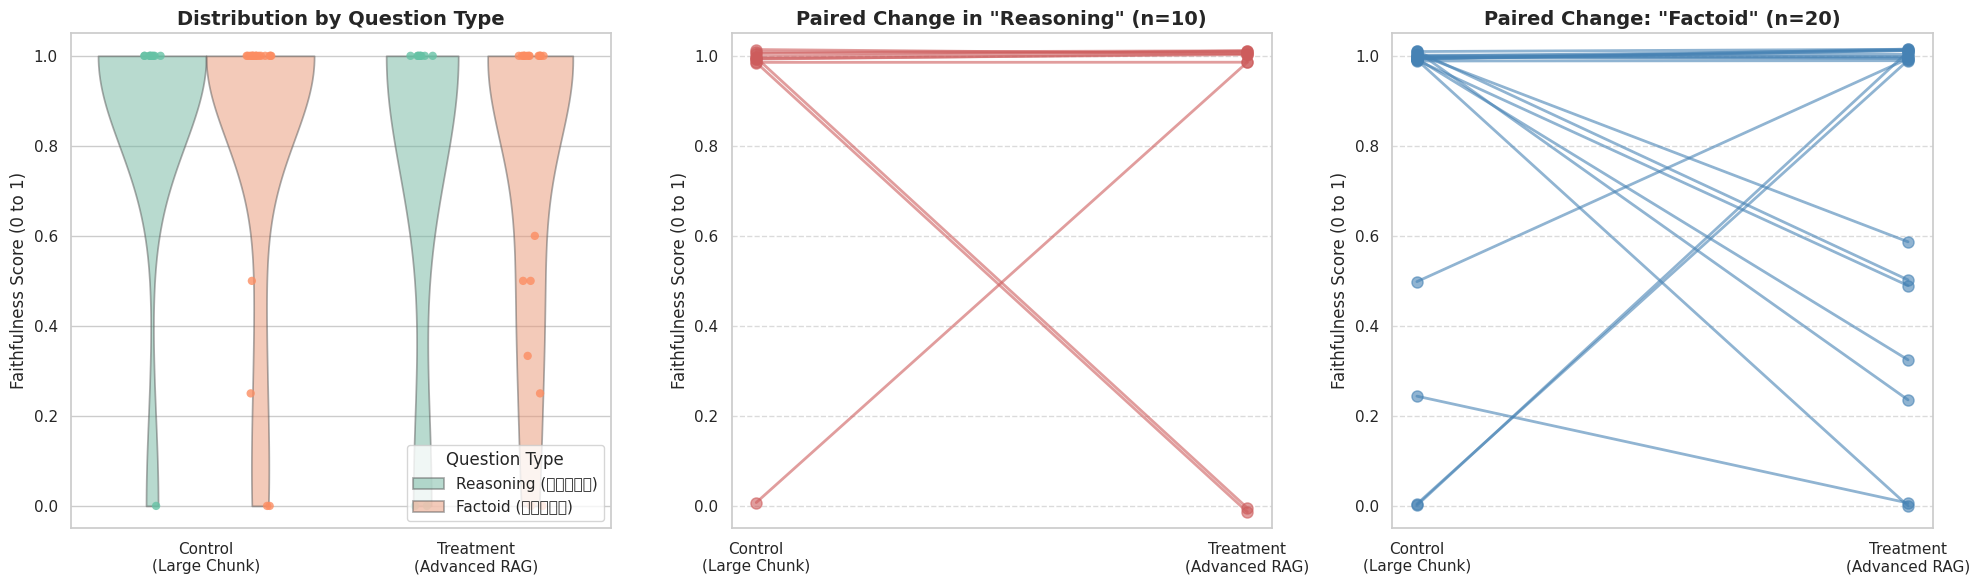

In [ ]:
import matplotlib.pyplot as plt
#グラフの土台を作るパッケージ
import seaborn as sns
#グラフを装飾するパッケージ
import pandas as pd
#表計算を行うパッケージ
import numpy as np
#数値計算を高速でするパッケージ

sns.set_theme(style="whitegrid")
#グラフを白背景と目盛りにグレーの横線を追加

df_melt = df_merged.melt(
#wide型からlong型のデータセットにする(バイオリンプロットの)
    id_vars=['question', 'question_type'],
#questionとquestion_typeの列を変化させないようにする
    value_vars=['faithfulness_control', 'faithfulness_treatment'],
#'faithfulness_control'と'faithfulness_treatment'の列を結合する
    var_name='System',
#元々の列の名前を収納する列を作成('faithfulness_control'と'faithfulness_treatment'を判別する列)
    value_name='Faithfulness_Score'
#実際のスコアを収納する列の追加('faithfulness_control'と'faithfulness_treatment'のスコアをまとめた列)
)

df_melt['System'] = df_melt['System'].replace({
#systemの列に入っている'faithfulness_control'と'faithfulness_treatment'を短い名前にする(X軸の下に表示される名前が重ならないようにするため)
    'faithfulness_control': 'Control\n(Large Chunk)',
    'faithfulness_treatment': 'Treatment\n(Advanced RAG)'
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
#二つのグラフを出力する全体のサイズと2つのグラフの枠を作成

# ① バイオリンプロット ＋ ストリッププロット
# スコアが密集し、見づらかったため、箱ひげ図ではなくデータの密度（太さ）を示すバイオリンプロットに変更
sns.violinplot(
#バイオリンプロットを描く
    data=df_melt, x='System', y='Faithfulness_Score', hue='question_type',
#df_meltのデータでX軸がsystem、Y軸がスコア、hueで色分けをする
    palette="Set2", ax=axes[0], inner=None, alpha=0.5, cut=0
#paletteで色の組み合わせ、axでグラフの枠を指定、innerでバイオリンプロット内に書くもの、alphaで透明度、cutでY軸方向の伸びを指定
)
# 実際のデータを点として描画（左右に散らす）
sns.stripplot(
#実際のデータを点として描画
    data=df_melt, x='System', y='Faithfulness_Score', hue='question_type',
#df_meltのデータでX軸がsystem、Y軸がスコア、hueで色分けをする
    palette="Set2", ax=axes[0], dodge=True, jitter=True, alpha=0.8, size=6
#paletteで色の組み合わせ、axでグラフの枠を指定、dodge=Trueで色分けしたグループごとで点の重なりを調整、alphaで透明度、jitterで意図的に点が1直線になるのを防ぐ、sizeは点サイズ
)

axes[0].set_title('Distribution by Question Type', fontsize=14, fontweight='bold')
#グラフのタイトル、フォントサイズ、フォントを設定
axes[0].set_ylabel('Faithfulness Score (0 to 1)', fontsize=12)
#y軸のラベルとフォントサイズを指定
axes[0].set_xlabel('')
#X軸のラベルを設定
axes[0].set_ylim(-0.05, 1.05)
#y軸の範囲を設定

handles, labels = axes[0].get_legend_handles_labels()
#色の説明書き(凡例)を1度全て取り出し、変数にしまう(ほぼ色が変わらないのに点とバイオリンプロットの説明が2度されるのを防ぐ)
axes[0].legend(handles[:2], labels[:2], title='Question Type', loc='lower right')
#凡例を最初の二つのみ取り出す


# ② 対応のあるスロープグラフ（Jitter追加）
df_reasoning = df_merged[df_merged['question_type'] == 'Reasoning (論理展開型)']
#論理展開型の問題のみ抜き出し、データフレームを作成
for idx, row in df_reasoning.iterrows():
#問題を1問ずつ抜き出す(iterrowsは1行ずつバラバラにする)
    jitter_ctrl = row['faithfulness_control'] + np.random.uniform(-0.015, 0.015)
#control群の各問題にランダムな微小な数字を足すことにより重なりを防ぐ
    jitter_trt = row['faithfulness_treatment'] + np.random.uniform(-0.015, 0.015)
#treatment群の各問題にランダムな微小な数字を足すことにより重なりを防ぐ
    axes[1].plot(
        ['Control\n(Large Chunk)', 'Treatment\n(Advanced RAG)'],
    #X軸のどこからどこまで引くかを指定
        [jitter_ctrl, jitter_trt],
    #Y軸のどこからどこまで引くかを指定
        marker='o', color='indianred', alpha=0.6, linewidth=2, markersize=8
    #marker='o'線の両端に〇のマークを追加、color='indianred': 色を、少し落ち着いた赤色にする、alpha=0.6: 線を60%の半透明にする、linewidth=2, markersize=8: 線の太さと、両端の丸の大きさ
    )

axes[1].set_title(f'Paired Change in "Reasoning" (n={len(df_reasoning)})', fontsize=14, fontweight='bold')
#グラフのタイトル、フォントサイズ、フォントを指定
axes[1].set_ylabel('Faithfulness Score (0 to 1)', fontsize=12)
#Y軸のラベル、フォントサイズを指定
axes[1].set_ylim(-0.05, 1.05)
#ｙ軸の範囲を設定
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
#横向きの補助線のみを描画、linestyle='--'により点線にし、alphaで透明度を指定
axes[1].grid(axis='x', visible=False)
#X軸方向に対しての補助線を非表示にする

# ③ 【右パネル(axes[2])】Factoid（事実検索型）のスロープグラフ
# 事実検索型のデータだけを抜き出す
df_factoid = df_merged[df_merged['question_type'] == 'Factoid (事実検索型)']

for idx, row in df_factoid.iterrows():
    jitter_ctrl = row['faithfulness_control'] + np.random.uniform(-0.015, 0.015)
    jitter_trt = row['faithfulness_treatment'] + np.random.uniform(-0.015, 0.015)

    axes[2].plot(
        ['Control\n(Large Chunk)', 'Treatment\n(Advanced RAG)'],
        [jitter_ctrl, jitter_trt],
        marker='o', color='steelblue', alpha=0.6, linewidth=2, markersize=8
    )

axes[2].set_title(f'Paired Change: "Factoid" (n={len(df_factoid)})', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Faithfulness Score (0 to 1)', fontsize=12)
axes[2].set_ylim(-0.05, 1.05)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].grid(axis='x', visible=False)


plt.tight_layout()
#文字や図形が重ならないように余白を調整
plt.savefig('rag_eval_viz.png', dpi=300, bbox_inches='tight')
#画像ファイルを保存(dpi=300は画像の解像度、bbox_inches='tight': 保存するときに、はみ出したタイトルやラベルが「見切れて（スパッと切られて）保存される」のを防ぐ)

plt.show()
#Colab上にも表示

###論理展開型の効果量分析(忠実性)



In [ ]:
import numpy as np

# 質問タイプ（ラベルの種類）を抽出
types = df_merged['question_type'].unique()

print("=== 効果量（Cohen's d）の分析 ===\n")

# ReasoningとFactoidの両方でループを回す！
for q_type in types:
    # 該当するグループのデータだけを抽出
    df_sub = df_merged[df_merged['question_type'] == q_type]

    # ControlとTreatmentのスコアを取得
    scores_ctrl = df_sub['faithfulness_control']
    #control群の忠実性スコアを抽出
    scores_trt = df_sub['faithfulness_treatment']
    #treatment群の忠実性スコアを抽出

    # 対応のあるデータの「差分」を計算
    diffs = scores_trt - scores_ctrl

    # 差分の平均（ATE）と、差分の不偏標準偏差を計算
    mean_diff = diffs.mean()
    sd_diff = diffs.std(ddof=1)

    # ゼロ割りエラーを防ぐ処理（もし全く同じ点数で標準偏差が0になった場合の保険）
    if sd_diff == 0:
        cohens_d = 0.0
    else:
        cohens_d = mean_diff / sd_diff

    print(f"■ {q_type} (n={len(df_sub)}) の効果量分析")
    #問題のタイプと問題数を表示
    print(f"  平均差 (ATE): {mean_diff:.4f}")
    #ATEを小数第4位まで表示
    print(f"  差の標準偏差 (SD): {sd_diff:.4f}")
    #差の標準偏差を小数第4位まで表示
    print(f"  Cohen's d: {cohens_d:.4f}")
    #効果量を小数第4位まで表示

    # Cohen's d の一般的な解釈基準（目安）
    abs_d = abs(cohens_d)
    if abs_d >= 0.8:
        interpretation = "大 (Large) - 実用上、極めて明確な差がある"
    elif abs_d >= 0.5:
        interpretation = "中 (Medium) - 実用上、意味のある差がある"
    elif abs_d >= 0.2:
        interpretation = "小 (Small) - 小さな差がある"
    else:
        interpretation = "ごくわずか (Trivial) - ほとんど差がない"

    print(f"  効果量の解釈: {interpretation}\n")

=== 効果量（Cohen's d）の分析 ===

■ Reasoning (論理展開型) (n=10) の効果量分析
  平均差 (ATE): -0.1000
  差の標準偏差 (SD): 0.5676
  Cohen's d: -0.1762
  効果量の解釈: ごくわずか (Trivial) - ほとんど差がない

■ Factoid (事実検索型) (n=20) の効果量分析
  平均差 (ATE): -0.0783
  差の標準偏差 (SD): 0.5056
  Cohen's d: -0.1549
  効果量の解釈: ごくわずか (Trivial) - ほとんど差がない



###対応のあるt検定(正確性)

In [ ]:
import pandas as pd
from scipy import stats

# 1. 前の工程で作ったマージ済みデータ(df_merged)から、正確性のスコアだけを抽出
scores_c = df_merged['correctness_control']
# 対照群（Control）の正確性スコア
scores_t = df_merged['correctness_treatment']
# 処置群（Treatment）の正確性スコア

# 2. 平均点の計算
print("【1. 正確性の全体平均】")
print(f"Control平均: {scores_c.mean():.3f} 点")
# Control群の平均点を出力
print(f"Treatment平均: {scores_t.mean():.3f} 点")
# Treatment群の平均点を出力

# 3. 対応のあるt検定の実行
t_stat, p_value = stats.ttest_rel(scores_c, scores_t)
# 2つの手法の点数リストを比較し、t値とp値を計算する
print("\n【2. 対応のあるt検定の結果】")
print(f"p値 (p-value): {p_value:.5f}")
# p値を表示

【1. 正確性の全体平均】
Control平均: 0.247 点
Treatment平均: 0.210 点

【2. 対応のあるt検定の結果】
p値 (p-value): 0.15596


###正確性においてスコア差が最もついた質問3つ

In [ ]:
# 1. 差分（Treatment - Control）を計算
df_merged['correctness_diff'] = df_merged['correctness_treatment'] - df_merged['correctness_control']
# 正確性（correctness）のスコアを使って、TreatmentからControlの点数を引き、新しい「差分」の列を作ります。

# 2. 差分が「プラス（Advancedの勝ち）」から「マイナス（Controlの勝ち）」の順に並べ替え
df_sorted_c = df_merged.sort_values(by='correctness_diff', ascending=False)
# 差分が大きい順（Treatmentが圧勝した順）に表を並べ替えて、df_sorted_c という新しい箱に入れます。

# 3. 見やすいように必要な列だけを表示（表示幅を広げる設定も追加）
pd.set_option('display.max_colwidth', None)
# 質問文が途中で「...」と省略されないように、セルの表示幅を無制限に設定します。
display_cols_c = ['question', 'correctness_control', 'correctness_treatment', 'correctness_diff']
# 表示させたい4つの列（質問、通常RAGの点数、Advanced RAGの点数、その差分）を指定します。

# 4. トップ3の表示
print("=== 【正確性】Advanced RAG が勝った（改善した）質問 トップ3 ===")
display(df_sorted_c[display_cols_c].head(3))
# 並べ替えた表の上から3行（head）を表示します。

# 5. ワースト3の表示
print("\n=== 【正確性】Control が勝った（Advanced RAGが大敗した）質問 ワースト3 ===")
display(df_sorted_c[display_cols_c].tail(3))
# 並べ替えた表の下から3行（tail）を表示します。

=== 【正確性】Advanced RAG が勝った（改善した）質問 トップ3 ===


,question,correctness_control,correctness_treatment,correctness_diff
29,加工食品のアレルギー表示において、「特定原材料（表示義務）」に指定されている8品目をすべて挙げてください。,0.184967,0.387544,0.202577
18,食物経口負荷試験（OFC）を複数回に分割して摂取する場合、摂取間隔は原則として何分以上あけることが望ましいですか？また鶏卵の場合はどうですか？,0.146304,0.191139,0.044834
16,アナフィラキシーの既往がない完全除去中の患者に対する牛乳のOFCで、ミルクの特異的IgE抗体価（ImmunoCAP法）がクラス1以下の場合、実施する医療機関の分類としてどこが該当しますか？,0.153287,0.182415,0.029128



=== 【正確性】Control が勝った（Advanced RAGが大敗した）質問 ワースト3 ===


,question,correctness_control,correctness_treatment,correctness_diff
10,抗原特異的IgE抗体検査において、アラスタット3g Allergyとイムノキャップの測定値は同一検体で完全に一致しますか？特に注意すべき食物は何ですか？,0.543512,0.172670,-0.370842
11,クルミおよびカシューナッツのアレルギー診断精度を高めるために、併用が推奨される保険収載のアレルゲンコンポーネント検査の項目はそれぞれ何ですか？,0.572599,0.197599,-0.375000
23,食物アレルギーの経口免疫療法（OIT）に関して、症状誘発の閾値が不明または低い症例に対し、自宅で原因食物を増量させる指導を行うことは推奨されますか？,0.714994,0.213865,-0.501130


###正確性においてのサブグループ解析（異質的処置効果の検証）

In [ ]:
import numpy as np
from scipy import stats

# 1. 質問を分類する関数を定義
def classify_question(text):
    # 論理や理由、複数要素を問うキーワード
    reasoning_keywords = ['なぜ', '理由', 'どのような', '病態', '方針', '違い', '注意点', '確認すべき']

    if any(keyword in text for keyword in reasoning_keywords):
        return 'Reasoning (論理展開型)'
    else:
        return 'Factoid (事実検索型)'

# 2. 分類結果を新しい列として追加
df_merged['question_type'] = df_merged['question'].apply(classify_question)

# 3. グループごとに集計とt検定を実行
types = df_merged['question_type'].unique()

print("=== 【正確性】サブグループ解析（異質的処置効果の検証） ===\n")

for q_type in types:
    # 該当するグループのデータを抽出
    df_sub = df_merged[df_merged['question_type'] == q_type]
    n_sub = len(df_sub)


    scores_ctrl = df_sub['correctness_control']
    scores_trt = df_sub['correctness_treatment']

    mean_ctrl = scores_ctrl.mean()
    mean_trt = scores_trt.mean()
    ate_sub = mean_trt - mean_ctrl

    # 対応のあるt検定
    t_stat, p_val = stats.ttest_rel(scores_trt, scores_ctrl)

    print(f"■ {q_type} (n={n_sub}問)")
    print(f"  Control平均: {mean_ctrl:.4f} | Treatment平均: {mean_trt:.4f}")
    print(f"  平均処置効果(ATE): {ate_sub:.4f} ポイント")
    print(f"  t値: {t_stat:.4f} | p値: {p_val:.4f}")

    if p_val < 0.05:
        print("  結論: 統計的に有意な差が確認されました！ (p < 0.05)\n")
    else:
        print("  結論: 統計的な有意差は確認されませんでした (p >= 0.05)\n")

=== 【正確性】サブグループ解析（異質的処置効果の検証） ===

■ Reasoning (論理展開型) (n=10問)
  Control平均: 0.1907 | Treatment平均: 0.1905
  平均処置効果(ATE): -0.0002 ポイント
  t値: -0.1652 | p値: 0.8725
  結論: 統計的な有意差は確認されませんでした (p >= 0.05)

■ Factoid (事実検索型) (n=20問)
  Control平均: 0.2750 | Treatment平均: 0.2195
  平均処置効果(ATE): -0.0555 ポイント
  t値: -1.4684 | p値: 0.1584
  結論: 統計的な有意差は確認されませんでした (p >= 0.05)



###箱ひげ図(バイオリンプロット)と対応のあるスロープグラフ(正確性)

/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 35542 (\N{CJK UNIFIED IDEOGRAPH-8AD6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_887/3213785679.py:84: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missi

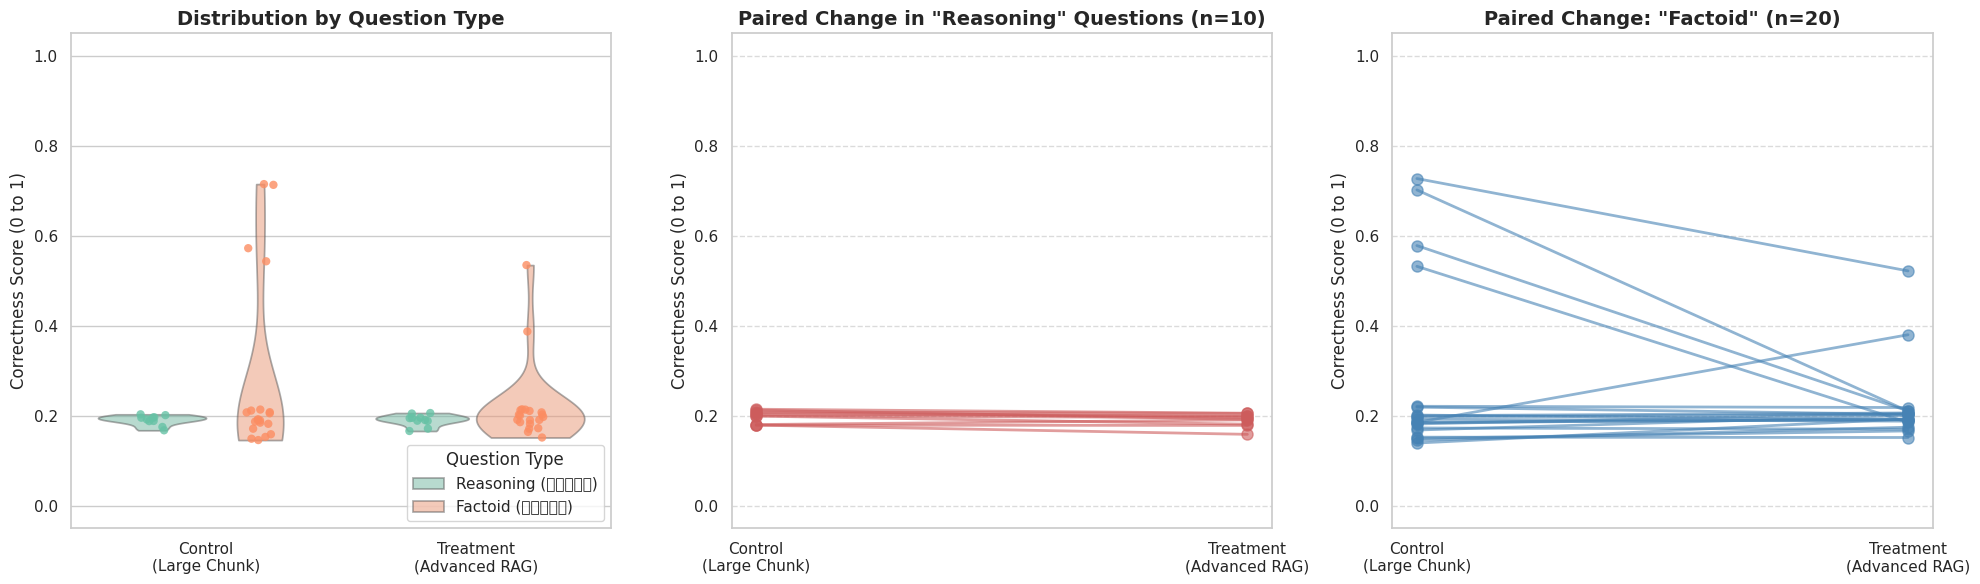

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# === 変更点1: faithfulness を correctness に変更 ===
df_melt = df_merged.melt(
    id_vars=['question', 'question_type'],
    value_vars=['correctness_control', 'correctness_treatment'],
    var_name='System',
    value_name='Correctness_Score'
)

df_melt['System'] = df_melt['System'].replace({
    'correctness_control': 'Control\n(Large Chunk)',
    'correctness_treatment': 'Treatment\n(Advanced RAG)'
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ① バイオリンプロット ＋ ストリッププロット
# 箱ひげ図をやめ、データの密度（太さ）を示すバイオリンプロットに変更
sns.violinplot(
    data=df_melt, x='System', y='Correctness_Score', hue='question_type',
    palette="Set2", ax=axes[0], inner=None, alpha=0.5, cut=0 # cut=0で0〜1の範囲に収める
)
# 実際のデータを点として描画（左右に散らす）
sns.stripplot(
    data=df_melt, x='System', y='Correctness_Score', hue='question_type',
    palette="Set2", ax=axes[0], dodge=True, jitter=True, alpha=0.8, size=6
)

axes[0].set_title('Distribution by Question Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Correctness Score (0 to 1)', fontsize=12) # 軸ラベルも変更
axes[0].set_xlabel('')
axes[0].set_ylim(-0.05, 1.05)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], labels[:2], title='Question Type', loc='lower right')

# ② 対応のあるスロープグラフ（Jitter追加）
df_reasoning = df_merged[df_merged['question_type'] == 'Reasoning (論理展開型)']

for idx, row in df_reasoning.iterrows():
    jitter_ctrl = row['correctness_control'] + np.random.uniform(-0.015, 0.015)
    jitter_trt = row['correctness_treatment'] + np.random.uniform(-0.015, 0.015)

    axes[1].plot(
        ['Control\n(Large Chunk)', 'Treatment\n(Advanced RAG)'],
        [jitter_ctrl, jitter_trt],
        marker='o', color='indianred', alpha=0.6, linewidth=2, markersize=8
    )


axes[1].set_title(f'Paired Change in "Reasoning" Questions (n={len(df_reasoning)})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Correctness Score (0 to 1)', fontsize=12)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].grid(axis='x', visible=False)


# ③ 【右パネル(axes[2])】Factoid（事実検索型）のスロープグラフ
df_factoid = df_merged[df_merged['question_type'] == 'Factoid (事実検索型)']

for idx, row in df_factoid.iterrows():
    # こちらも correctness のデータを使用
    jitter_ctrl = row['correctness_control'] + np.random.uniform(-0.015, 0.015)
    jitter_trt = row['correctness_treatment'] + np.random.uniform(-0.015, 0.015)

    axes[2].plot(
        ['Control\n(Large Chunk)', 'Treatment\n(Advanced RAG)'],
        [jitter_ctrl, jitter_trt],
        marker='o', color='steelblue', alpha=0.6, linewidth=2, markersize=8
    )

axes[2].set_title(f'Paired Change: "Factoid" (n={len(df_factoid)})', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Correctness Score (0 to 1)', fontsize=12)
axes[2].set_ylim(-0.05, 1.05)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].grid(axis='x', visible=False)

plt.tight_layout()

plt.savefig('rag_eval_viz_correctness_3.png', dpi=300, bbox_inches='tight')

# 最後にColab上にも表示
plt.show()

###論理展開型の効果量分析(正確性)

In [ ]:
import numpy as np

# 質問タイプ（ラベルの種類）を抽出
types = df_merged['question_type'].unique()

print("=== 効果量（Cohen's d）の分析 ===\n")

# ReasoningとFactoidの両方でループを回す！
for q_type in types:
    # 該当するグループのデータだけを抽出
    df_sub = df_merged[df_merged['question_type'] == q_type]

    # ControlとTreatmentのスコアを取得
    scores_ctrl = df_sub['correctness_control']
    scores_trt = df_sub['correctness_treatment']

    # 対応のあるデータの「差分」を計算
    diffs = scores_trt - scores_ctrl

    # 差分の平均（ATE）と、差分の不偏標準偏差を計算
    mean_diff = diffs.mean()
    sd_diff = diffs.std(ddof=1)

    # ゼロ割りエラーを防ぐ処理（もし全く同じ点数で標準偏差が0になった場合の保険）
    if sd_diff == 0:
        cohens_d = 0.0
    else:
        cohens_d = mean_diff / sd_diff

    print(f"■ {q_type} (n={len(df_sub)}) の効果量分析")
    print(f"  平均差 (ATE): {mean_diff:.4f}")
    print(f"  差の標準偏差 (SD): {sd_diff:.4f}")
    print(f"  Cohen's d: {cohens_d:.4f}")

    # Cohen's d の一般的な解釈基準（目安）
    abs_d = abs(cohens_d)
    if abs_d >= 0.8:
        interpretation = "大 (Large) - 実用上、極めて明確な差がある"
    elif abs_d >= 0.5:
        interpretation = "中 (Medium) - 実用上、意味のある差がある"
    elif abs_d >= 0.2:
        interpretation = "小 (Small) - 小さな差がある"
    else:
        interpretation = "ごくわずか (Trivial) - ほとんど差がない"

    print(f"  効果量の解釈: {interpretation}\n")

=== 効果量（Cohen's d）の分析 ===

■ Reasoning (論理展開型) (n=10) の効果量分析
  平均差 (ATE): -0.0002
  差の標準偏差 (SD): 0.0039
  Cohen's d: -0.0522
  効果量の解釈: ごくわずか (Trivial) - ほとんど差がない

■ Factoid (事実検索型) (n=20) の効果量分析
  平均差 (ATE): -0.0555
  差の標準偏差 (SD): 0.1692
  Cohen's d: -0.3283
  効果量の解釈: 小 (Small) - 小さな差がある



<details>
<summary>自分用メモ</summary>

- **importとfromの違い**
  - import:パッケージごと持ってくる
  - from ～ import: パッケージ内の必要なツールのみ持ってくる

- **!pip install -q**
  - pip install: Pythonに外部パッケージをインストールするための基本コマンド。
  - !: Google Colabに対して「これはPythonのプログラミングコードではなく、パソコン（OS）に直接命令するコマンド」と伝えるための記号。
  - -q: 通常インストールすると「〇〇をダウンロード中…〇〇%」といった文字が画面を埋め尽くすのを、非表示にして見た目をスッキリさせるためのオプション。
- **[item["question"] for item in qa_data]**
  - 「qa_data から1個ずつデータを取り出し（for）、そこから質問文だけを引っこ抜く（item["question"]）。これを30個全部終わるまで繰り返す。」外側を[]でくくることでリストにする
- **なぜ点数がリストでなく辞書なのか？**
辞書だと点数と手法で1セットにできるから
- **for i in tqdm(range(0, len(base_nodes), 10))**
  - range(スタートの数, ストップの数, スキップの数)
  - tqdm(...) ()内のループが回るたびに進捗を表示
  - for 表の一行 in 表全体
- try ～ except

tryは例外が発生するかもしれない処理、exceptは想定された例外が発生した時どのように処理するか
- str()

「レスポンスオブジェクト」という複雑なデータの塊（回答の文字以外にも、どんな設定で答えたか等の裏データも含まれている状態）から余計な裏データは捨てて、純粋な『文字（テキスト）』の部分だけを抽出させる
- response.source_nodes

responceを定義する時に同時に生成された参考資料のノードの束
- 解答生成モデル、採点モデル、埋め込みモデルの仕事
  - 解答生成モデル:参考資料の内容を理解し、質問の解答となるところのみ抽出、文章の構築
  - 採点モデル:作成された解答から、事実を抜き出し、資料のどこから推論できるかをチェック、採点する
  - 埋め込みモデル:テキストデータをベクトルに変換しコサイン類似度などを計算
- ascending=False:降順
- .apply():作成した関数を適応
- df_merged[df_merged['question_type'] == q_type]:「内側で〇×クイズのリストを作り、外側の [ ] に渡して〇の行だけ残す！」
- df_merged
  - 役割1:列の追加、選択df_merged[]
  - 役割2:行の絞り込み
  df_merged[条件式]
- extend:複数の破片が入ったリストを「箱ごと」入れるのではなく、「中身をバラして1つずつ追加する」
</details>

<details>
<summary>用語一覧</summary>


* 非同期処理:ある処理の完了を待たずに次のタスクを進める処理方式
*  LlamaIndex:RAGアプリを作るためのフレームワーク」。
   - PDF、Word、Excel、Webサイトなど、あらゆる形式のファイルから純粋な「テキストデータ」を抽出する。
   - GeminiなどをLlamaIndexの「規格」に合わせることで、自動で連携してくれる。
   - 抽出した長いテキストを、AIが一度に飲み込めるサイズ（512文字など）に切り分ける。
   - 切り分けたテキストを「埋め込みモデル」に渡し、「これをベクトル化して！」と指示を出す。そして返ってきたベクトルデータを、検索しやすいようにデータベースに綺麗に並べて保存する。
   - ユーザーから質問が来たら、データベースから関連するテキストを探し出し、「解答生成モデル」に渡して回答を作らせる。
* ノード:細かく切り分けたテキストブロック一つ一つのこと
* 後読み:文字を消さずに「。」「！」「？」の直後で分割する
* 改行ノイズ：文の途中なのにレイアウトの関係で入り込んだ\n のこと

